In [1]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [2]:
torch.backends.mkldnn.enabled = True

In [3]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [4]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    # nn.Conv2d(30, 30, 1),   # pointwise conv
    # nn.BatchNorm2d(30),
    # nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 32 → 16

    # nn.Conv2d(30, 30, 1),   # pointwise conv
    # nn.BatchNorm2d(30),
    # nn.PReLU(),
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 16 → 8

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 120, 3, padding=1, groups=60),
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 3, padding=1, groups=120),
    nn.BatchNorm2d(120),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 8 → 4

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.PReLU(),
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(120, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 4 → 2

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [5]:
model22_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model22_0)
describe(model22_0)

MACs: 4.18 MMac, Params: 54.09 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─MaxPool2d: 3-8               [1, 30, 16, 16]           --
│    └─Sequential: 2-2                   [1, 60, 8, 8]             --
│    │    └─Conv2d: 3-9                  [1, 60, 16, 

Loading checkpoint from model_weights/model22_0.pt
Starting
Epoch 1/60: Train loss = 1.1655, Train accuracy = 0.5811, Test loss = 1.1026, Test accuracy = 0.6034
Epoch 2/60: Train loss = 0.8809, Train accuracy = 0.6882, Test loss = 0.8533, Test accuracy = 0.7009
Epoch 3/60: Train loss = 0.7841, Train accuracy = 0.7249, Test loss = 0.7699, Test accuracy = 0.7345
Epoch 4/60: Train loss = 0.7271, Train accuracy = 0.7432, Test loss = 0.7440, Test accuracy = 0.7481
Epoch 5/60: Train loss = 0.8241, Train accuracy = 0.7126, Test loss = 0.8918, Test accuracy = 0.6984
Epoch 6/60: Train loss = 0.7183, Train accuracy = 0.7519, Test loss = 0.7605, Test accuracy = 0.7412
Epoch 7/60: Train loss = 0.6323, Train accuracy = 0.7785, Test loss = 0.6506, Test accuracy = 0.7768
Epoch 8/60: Train loss = 0.7137, Train accuracy = 0.7566, Test loss = 0.7414, Test accuracy = 0.7502
Epoch 9/60: Train loss = 0.6193, Train accuracy = 0.7859, Test loss = 0.6924, Test accuracy = 0.7720
Epoch 10/60: Train loss = 0.702

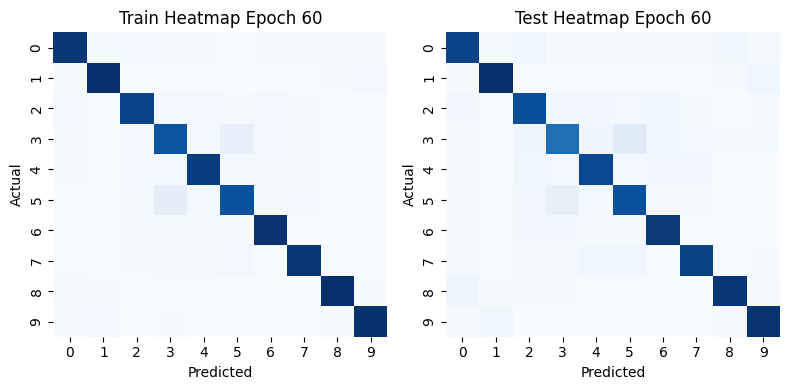

<Figure size 1200x600 with 0 Axes>

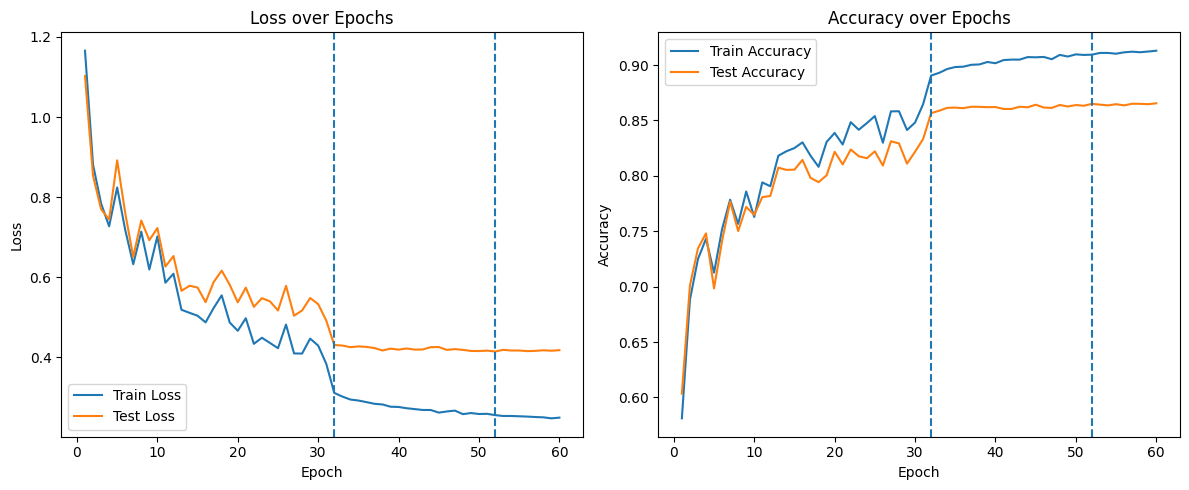

In [6]:
trainf32(model22_0,"model_weights/model22_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [7]:
model22_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model22_1)
describe(model22_1)

MACs: 4.18 MMac, Params: 54.09 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─MaxPool2d: 3-8               [1, 30, 16, 16]           --
│    └─Sequential: 2-2                   [1, 60, 8, 8]             --
│    │    └─Conv2d: 3-9                  [1, 60, 16, 

Starting


/home/saptak/.local/lib/python3.14/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 1/60: Train loss = 1.1002, Train accuracy = 0.6182, Test loss = 1.0728, Test accuracy = 0.6212
Epoch 2/60: Train loss = 0.8668, Train accuracy = 0.6974, Test loss = 0.8552, Test accuracy = 0.7031
Epoch 3/60: Train loss = 0.8942, Train accuracy = 0.6950, Test loss = 0.9096, Test accuracy = 0.6928
Epoch 4/60: Train loss = 0.7016, Train accuracy = 0.7569, Test loss = 0.7199, Test accuracy = 0.7506
Epoch 5/60: Train loss = 0.6245, Train accuracy = 0.7824, Test loss = 0.6423, Test accuracy = 0.7787
Epoch 6/60: Train loss = 0.6427, Train accuracy = 0.7800, Test loss = 0.6487, Test accuracy = 0.7822
Epoch 7/60: Train loss = 0.6030, Train accuracy = 0.7910, Test loss = 0.6180, Test accuracy = 0.7862
Epoch 8/60: Train loss = 0.5527, Train accuracy = 0.8062, Test loss = 0.5797, Test accuracy = 0.8029
Epoch 9/60: Train loss = 0.5173, Train accuracy = 0.8195, Test loss = 0.5538, Test accuracy = 0.8082
Epoch 10/60: Train loss = 0.5502, Train accuracy = 0.8075, Test loss = 0.6025, Test accurac

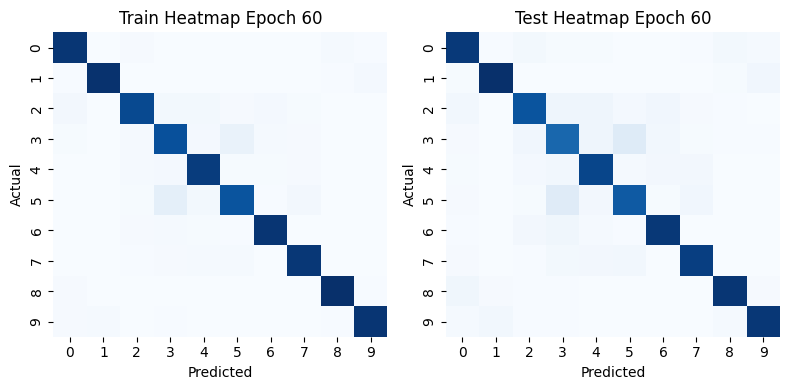

<Figure size 1200x600 with 0 Axes>

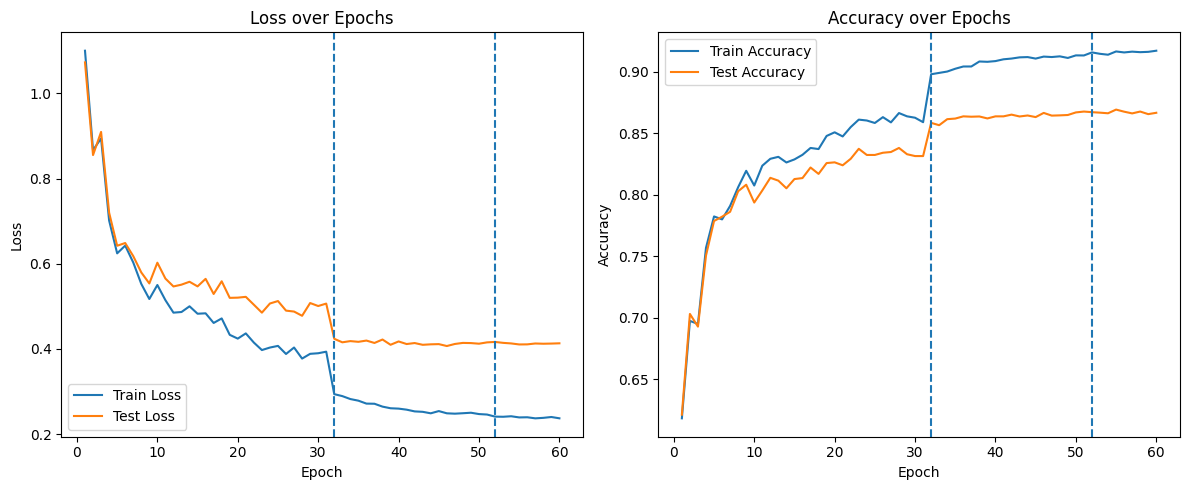

In [8]:
trainf32(model22_1,"model_weights/model22_1.pt",criterion,train_dataset,val_dataset, batch_size=64)